# TU simulation safety parameter plots

In [28]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [29]:
planning_simulations = False

# Determine simulation location
if planning_simulations:
    simulations_location = 'planning'
else:
    simulations_location = 'post-hoc'

# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/{simulations_location}'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

### Find all csv's from the stimulation output folder

In [30]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/{simulations_location}/'

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

stimulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)
print(stimulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-052/sub-052_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-053/sub-053_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-054/sub-054_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_1/sub-057/sub-057_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_2/sub-052/sub-052_layered_output_table_target_1_2_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_2/sub-053/sub-053_layered_output_table_target_1_2_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/target_1_2/sub-054/sub-054_layered_output_table_target_1_2_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/post-hoc/

### Save them in one dataframe
And add columns with the individual subject_id's, targets etc

In [31]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for stimulation_output_full_filename in stimulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(stimulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]
    
    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')
    
    # Extract the desired parts from the filename:
    subject_id = stimulation_output_filename_parts[0]                     # e.g. 'sub-010'
    target = '_'.join(stimulation_output_filename_parts[4:7])               # e.g. 'target_2_2'
    
    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(stimulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {stimulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the extracted metadata as new columns
    df['target'] = target
    
    # Append the dataframe to our list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

    subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0           52  31.289100                   15.303760                  1.0   
1           53  32.323870                   18.213490                  2.5   
2           54  35.914700                   16.895260                  2.0   
3           57  37.073910                   15.627630                  2.5   
4           52  36.716920                   19.060170                  3.0   
..         ...        ...                         ...                  ...   
74          52   6.379790                    6.379790                 13.5   
75          57   6.406937                    6.406937                 13.5   
76          54   7.123804                    7.123804                 15.0   
77          53   7.223487                    7.223487                 14.5   
78          55   6.792350                    6.792350                 15.0   

    max_Isppa_skin  max_Isppa_skull  max_Isppa_brain  max_press

### Reorder the dataframe and replace strings

In [32]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)

# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

    subject_id  CEM43_end_skull  CEM43_end_skin      target  max_Isppa  \
0           52         0.001131        0.000612  target_1_1  31.289100   
1           52         0.002002        0.001106  target_1_2  36.716920   
2           52         0.003161        0.001897  target_1_3  33.717870   
3           52         0.004917        0.002590  target_1_4  32.974140   
4           52         0.005674        0.003547  target_1_5  33.717870   
..         ...              ...             ...         ...        ...   
74          57         0.000555        0.000549  target_3_2   6.818221   
75          57         0.000812        0.000816  target_3_3   6.917089   
76          57         0.001112        0.001112  target_3_4   7.241661   
77          57         0.001386        0.001375  target_3_5   7.153579   
78          57         0.001740        0.001732  target_3_6   6.406937   

    max_Isppa_after_exit_plane  max_Isppa_skin  max_Isppa_skull  \
0                    15.303760       15.3037

# Mechanical index
1.9 is the safety limit
Group by target and intensity

In [33]:
safety_limit = 1.9

## Skin

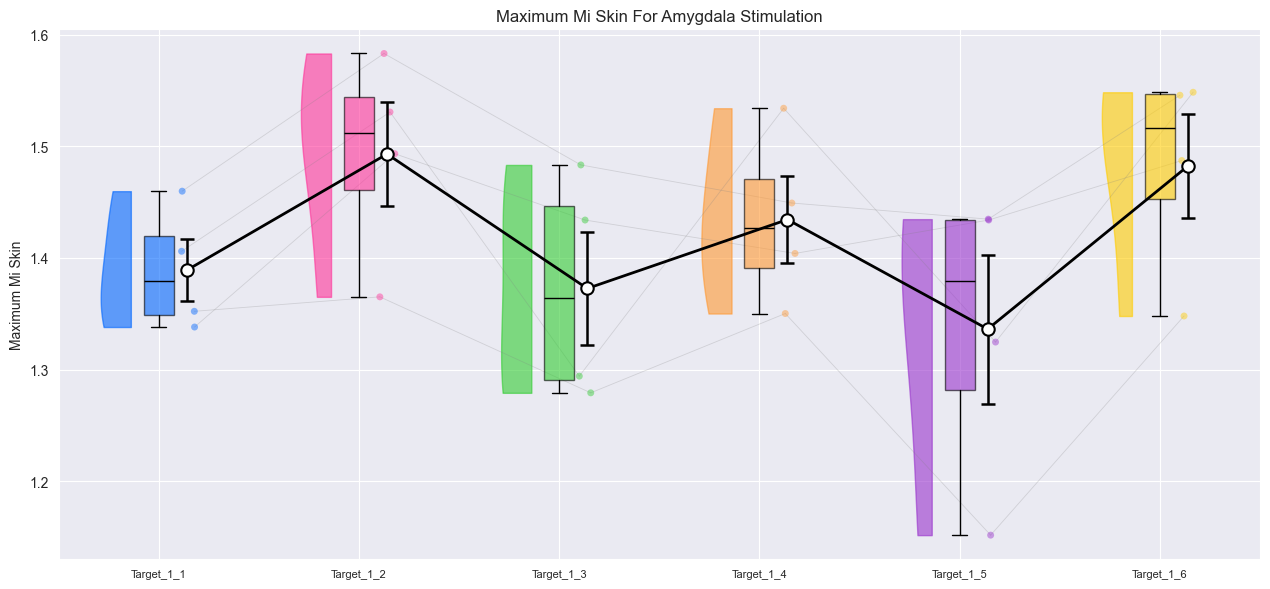

In [34]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI Skin',
    plot_name='Maximum MI Skin for Amygdala stimulation'
);

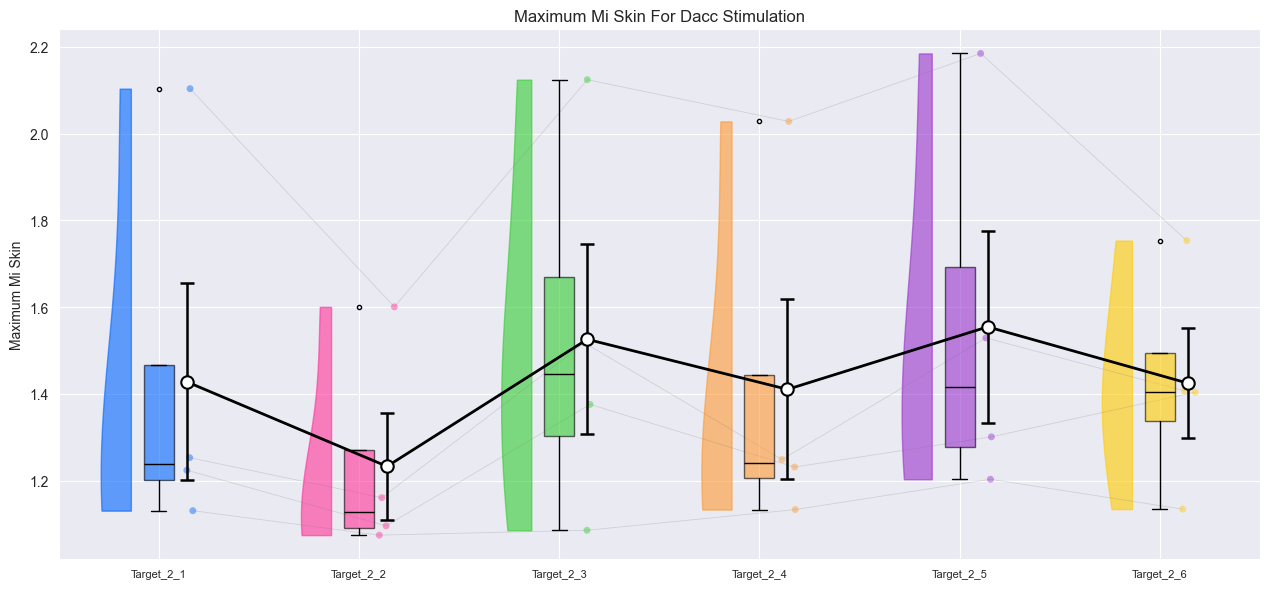

In [35]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI Skin',
    plot_name='Maximum MI Skin for dACC stimulation'
);

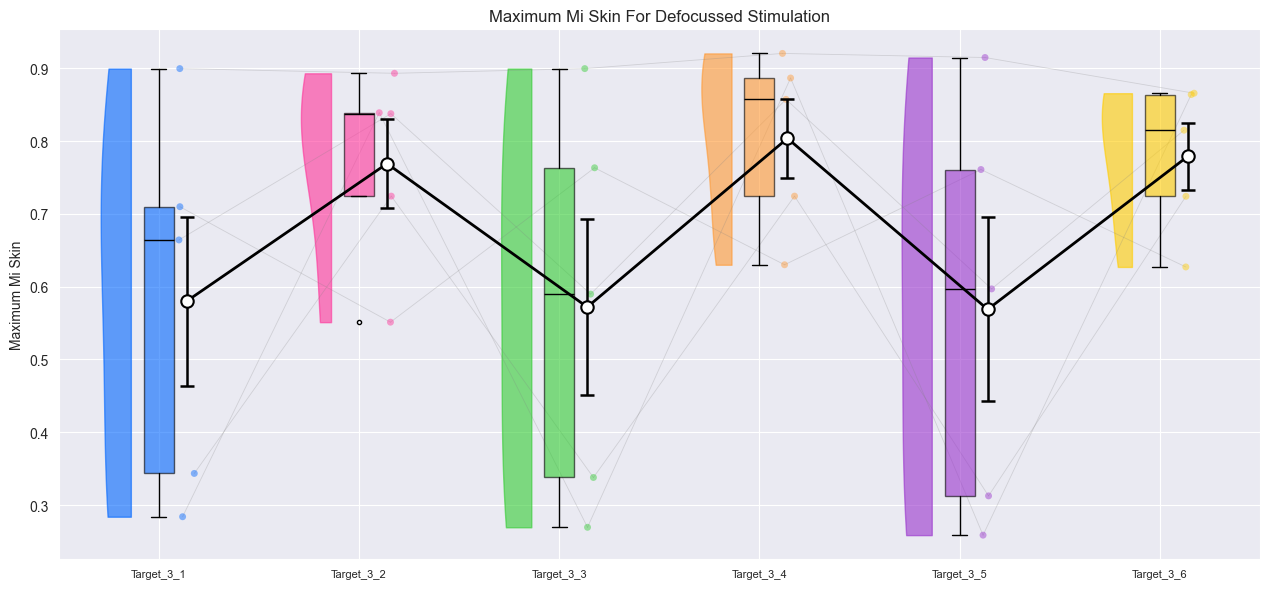

In [36]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI Skin',
    plot_name='Maximum MI Skin for defocussed stimulation'
);

## Brain

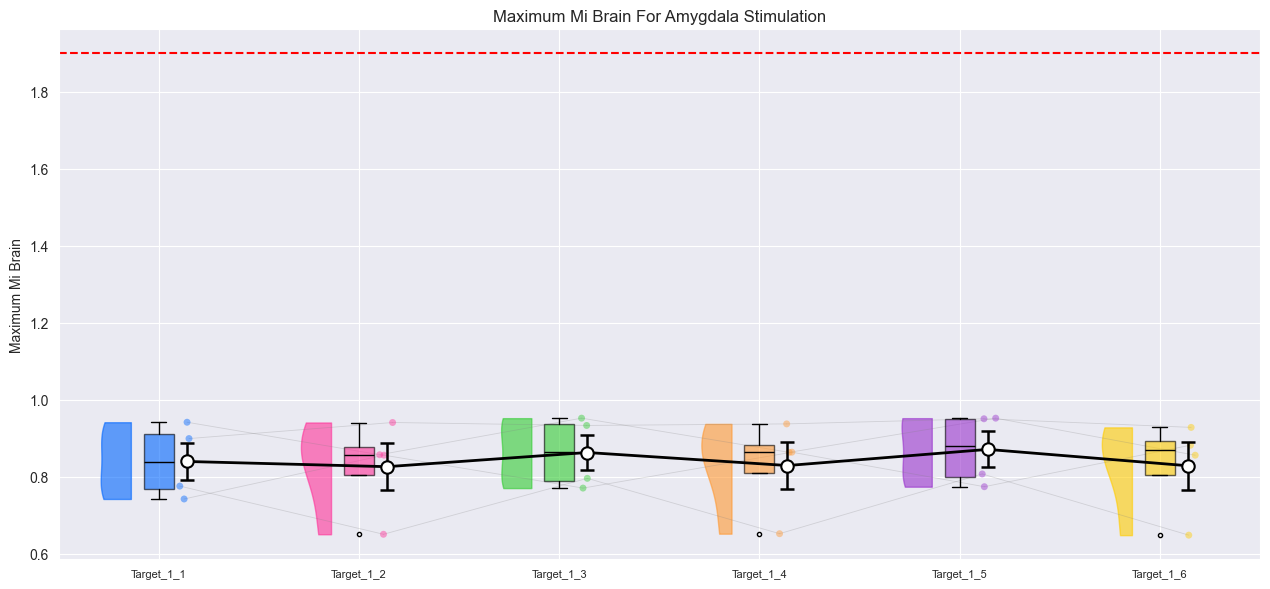

In [37]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI brain',
    hline=safety_limit,
    plot_name='Maximum MI brain for Amygdala stimulation'
);

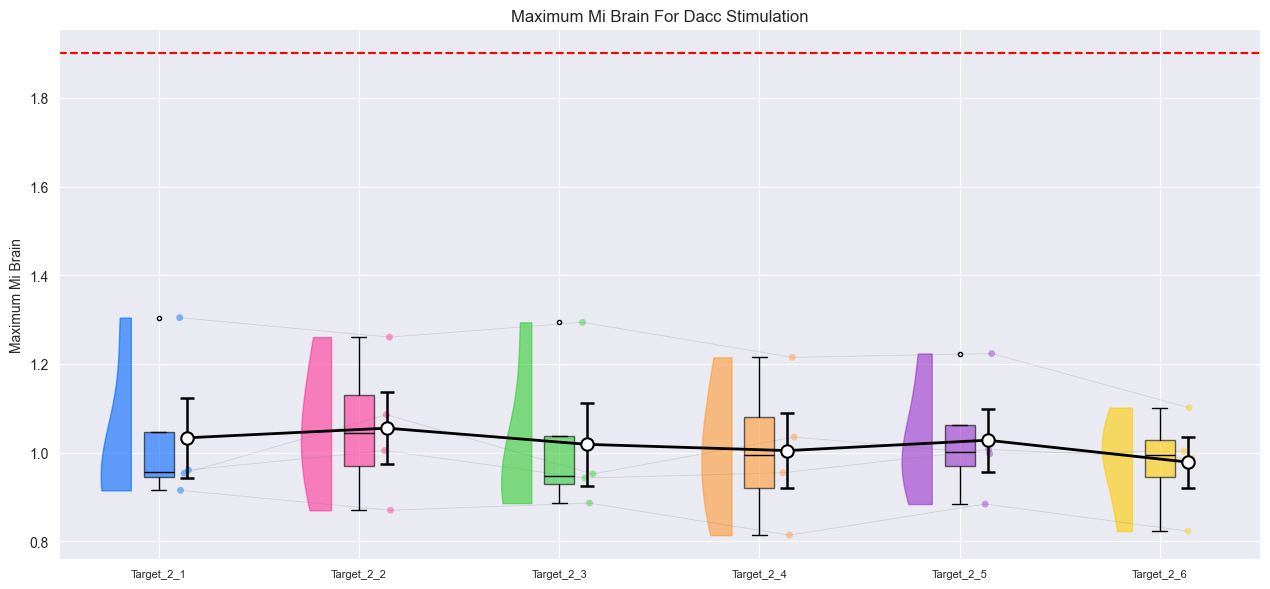

In [38]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI brain',
    hline=safety_limit,
    plot_name='Maximum MI brain for dACC stimulation'
);

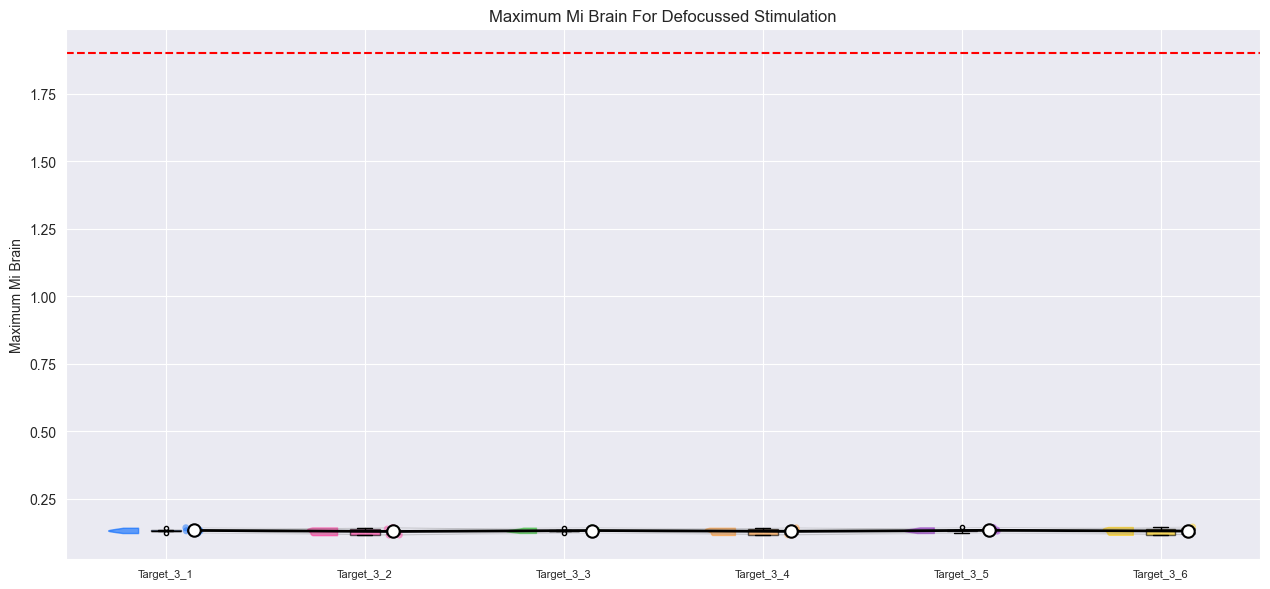

In [39]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI brain',
    hline=safety_limit,
    plot_name='Maximum MI brain for defocussed stimulation'
);

## Skull

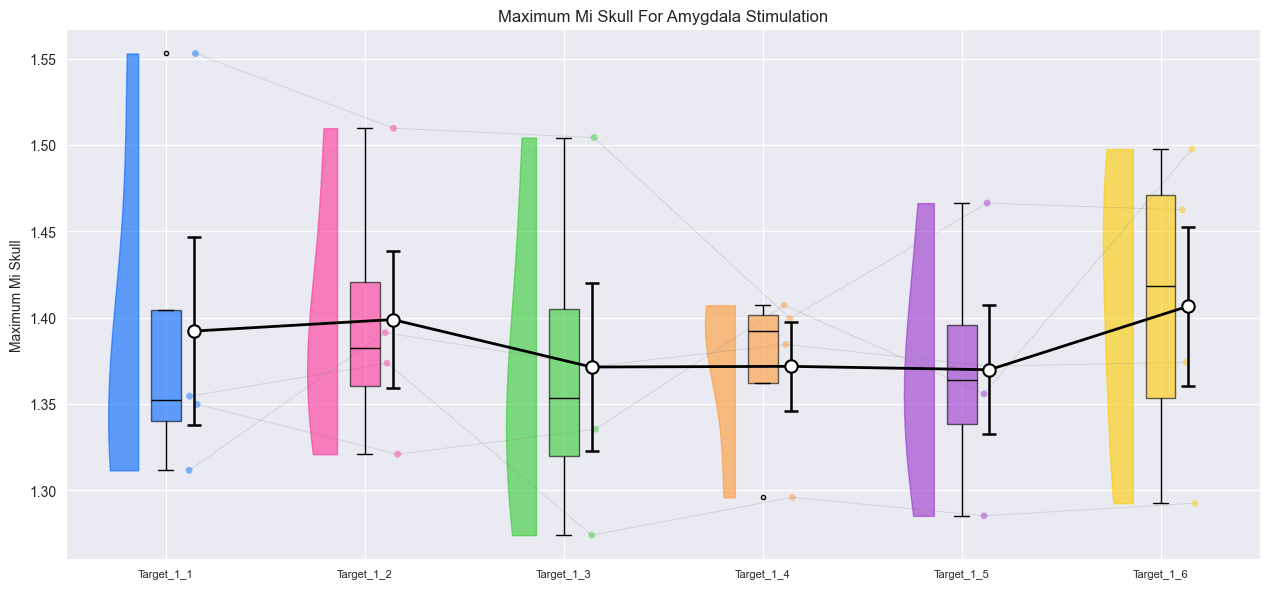

In [40]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI skull',
    plot_name='Maximum MI skull for Amygdala stimulation'
);

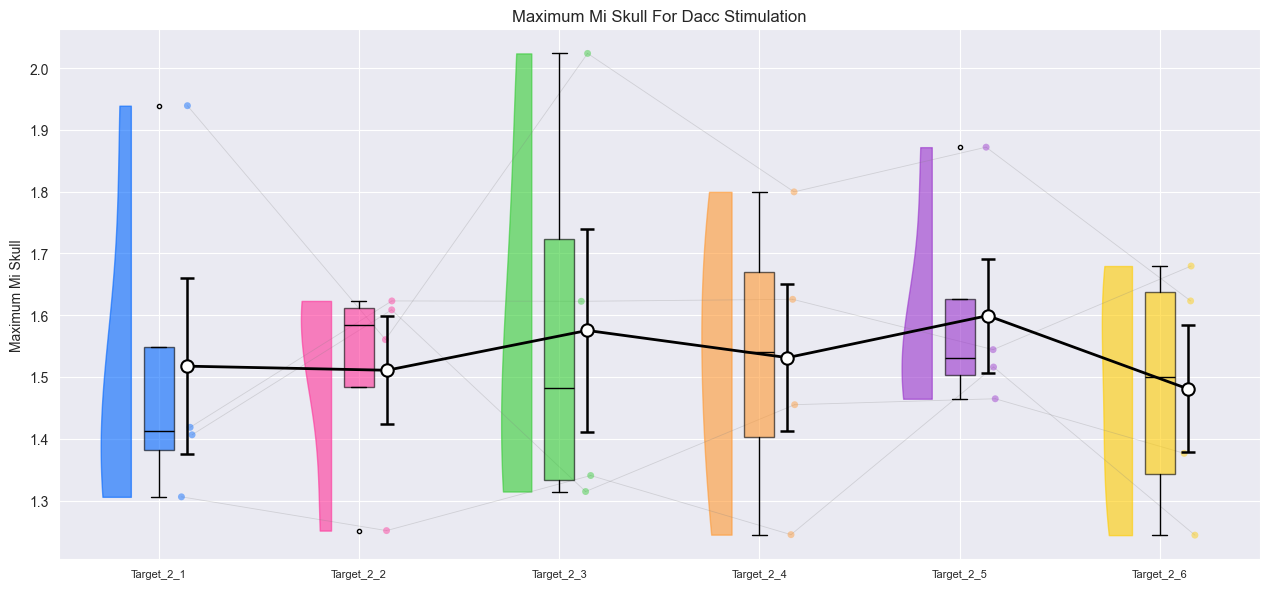

In [41]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI skull',
    plot_name='Maximum MI skull for dACC stimulation'
);

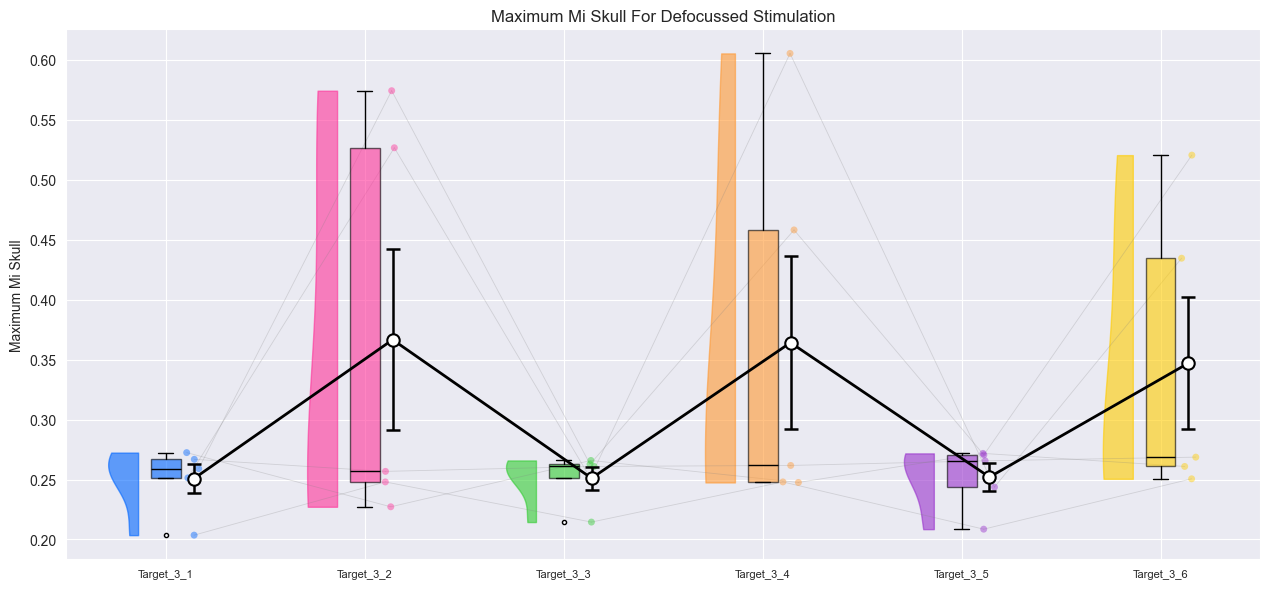

In [42]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='max_MI_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum MI skull',
    plot_name='Maximum MI skull for defocussed stimulation'
);

# CEM43
0.25 is the safety limit
Group by target and intensity

## Skin

In [43]:
safety_limit = 0.25 # ITRUSST 21

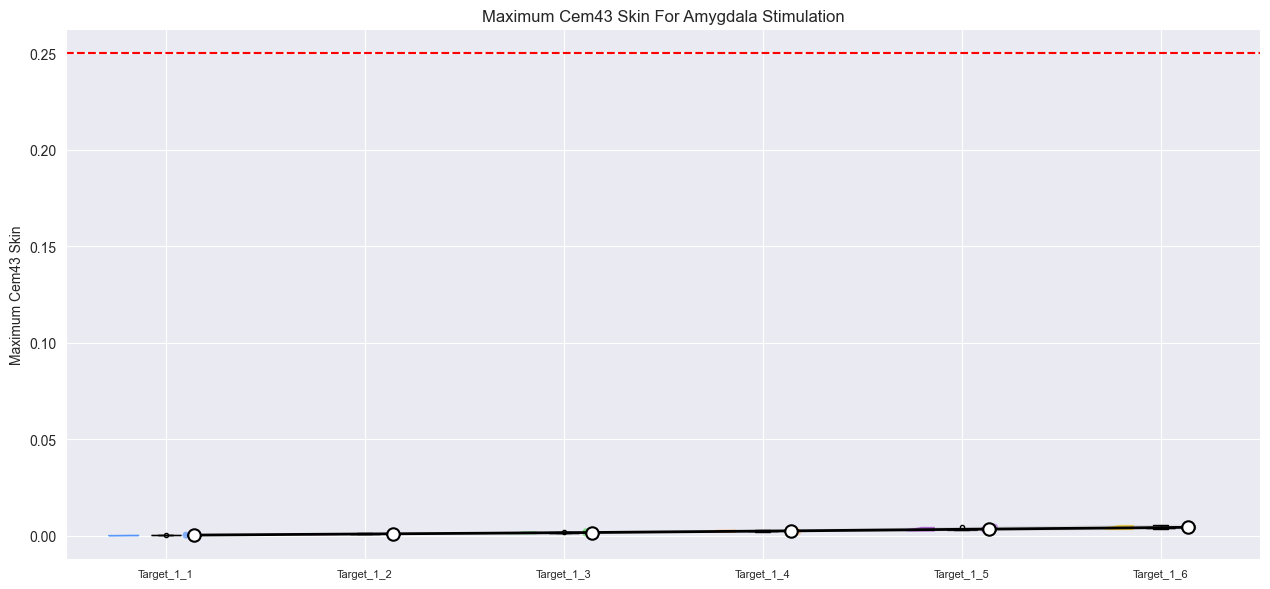

In [44]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 skin',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin for Amygdala stimulation'
);

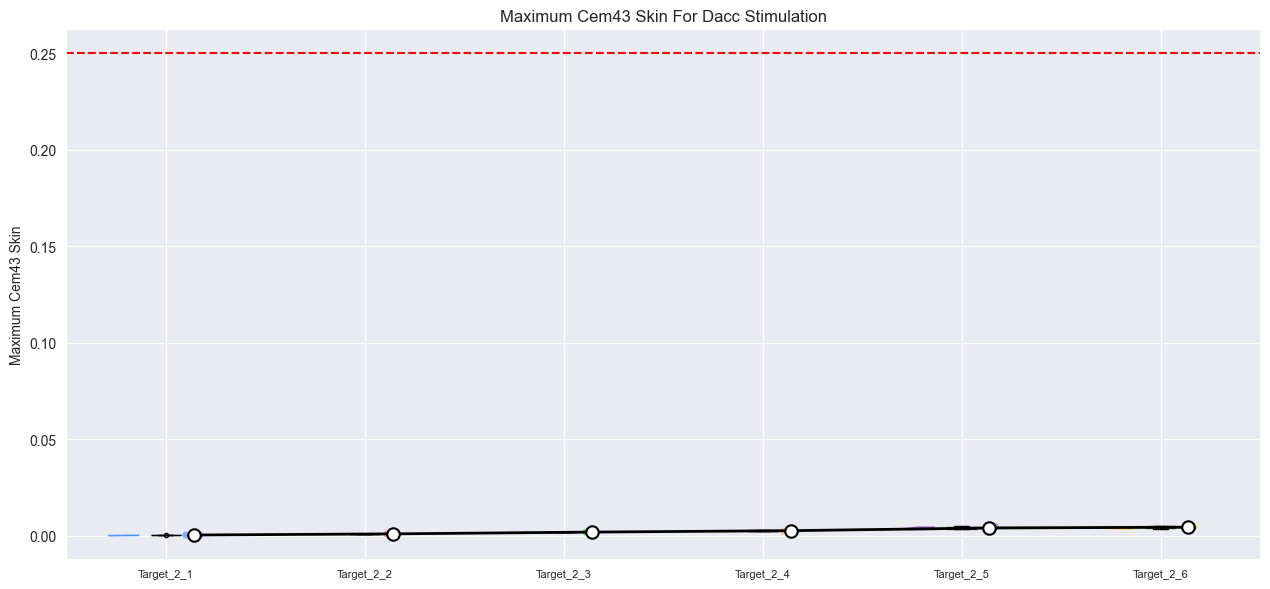

In [45]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 Skin',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin for dACC stimulation'
);

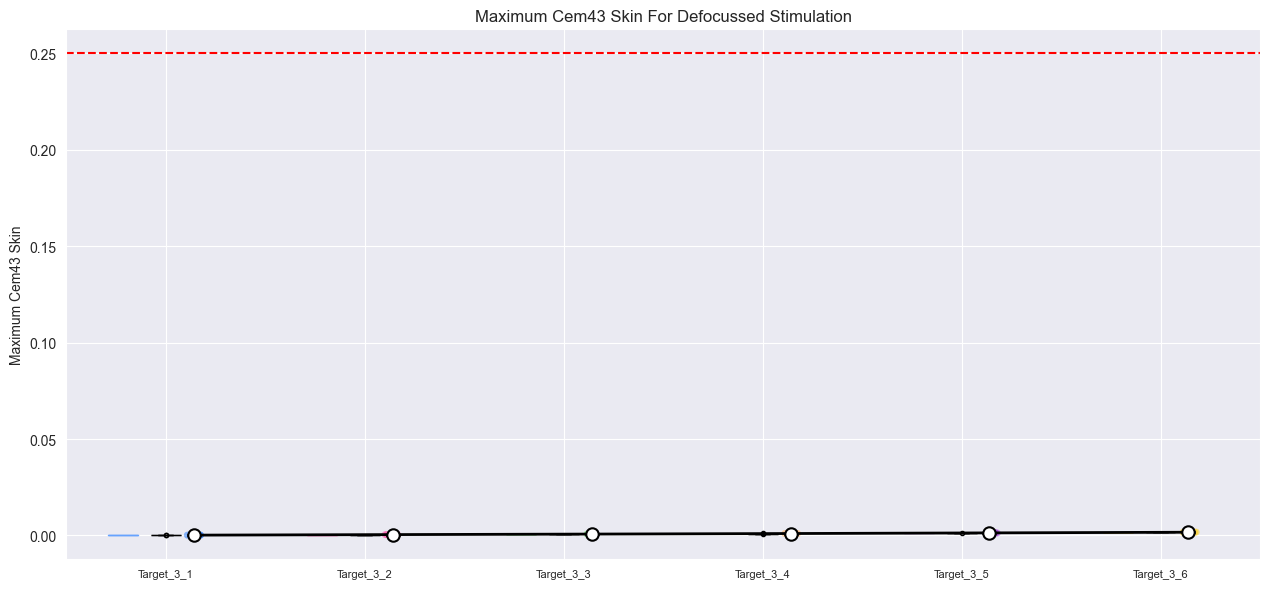

In [46]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skin',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 Skin',
    hline=safety_limit,
    plot_name='Maximum CEM43 Skin for defocussed stimulation'
);

## Brain

In [47]:
safety_limit = 0.25 # ITRUSST 2

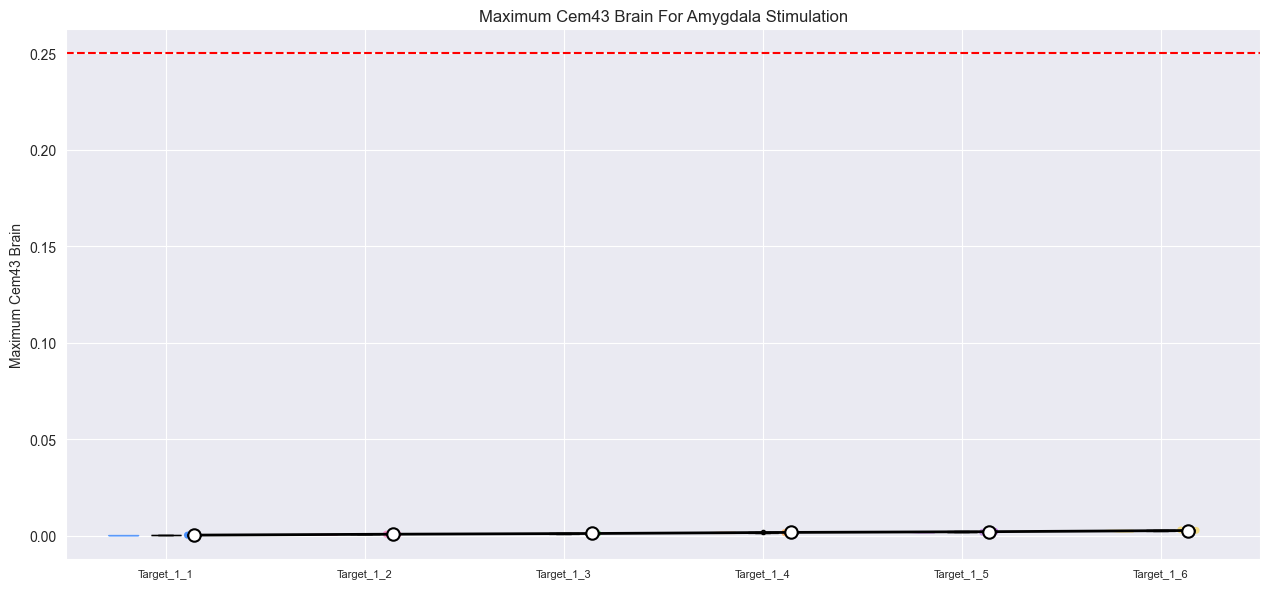

In [48]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 brain',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain for Amygdala stimulation'
);

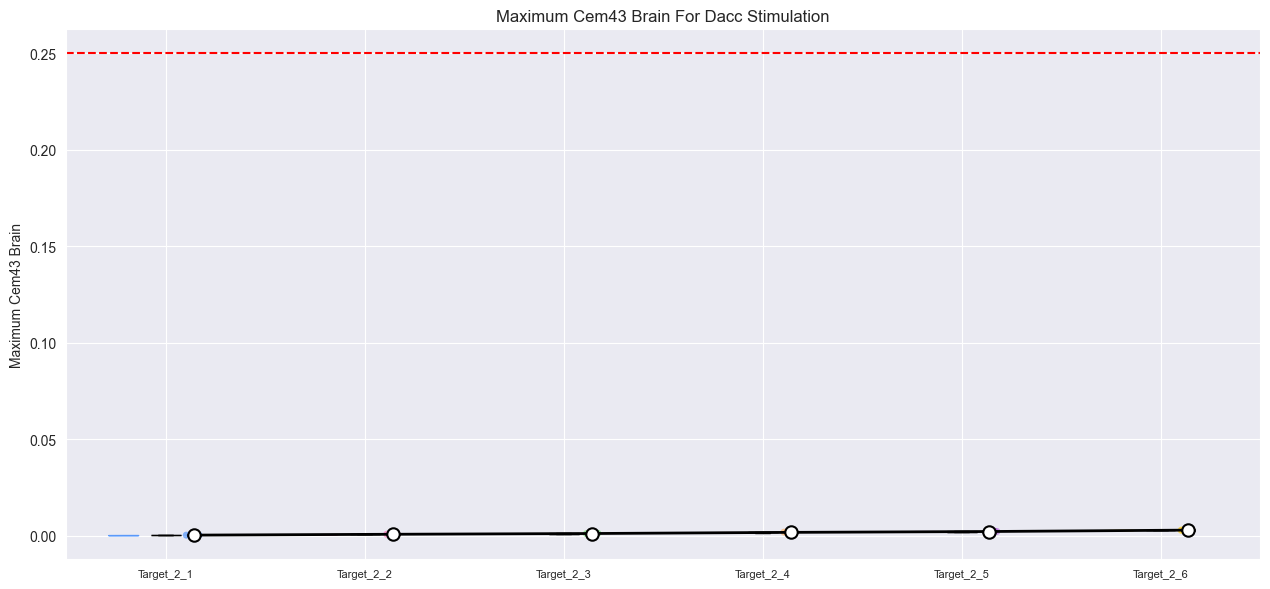

In [49]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 brain',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain for dACC stimulation'
);

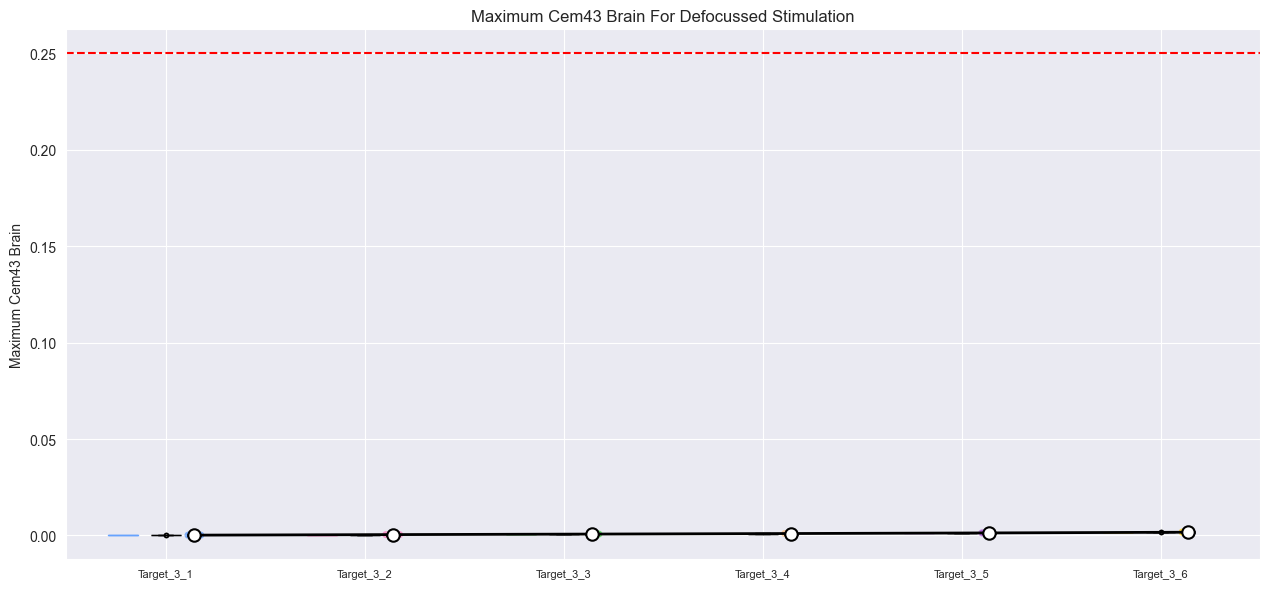

In [50]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_brain',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 brain',
    hline=safety_limit,
    plot_name='Maximum CEM43 brain for defocussed stimulation'
);

## Skull

In [51]:
safety_limit = 0.25 # ITRUSST 16

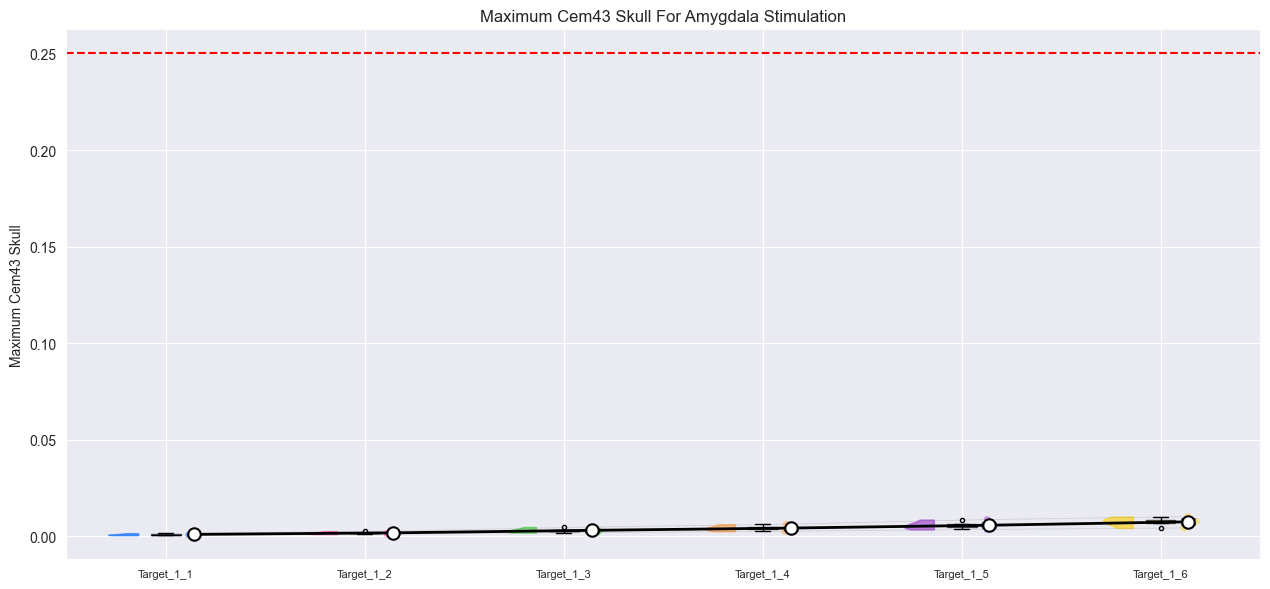

In [52]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_1_1', 'target_1_2', 'target_1_3', 'target_1_4', 'target_1_5', 'target_1_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 skull',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull for Amygdala stimulation'
);

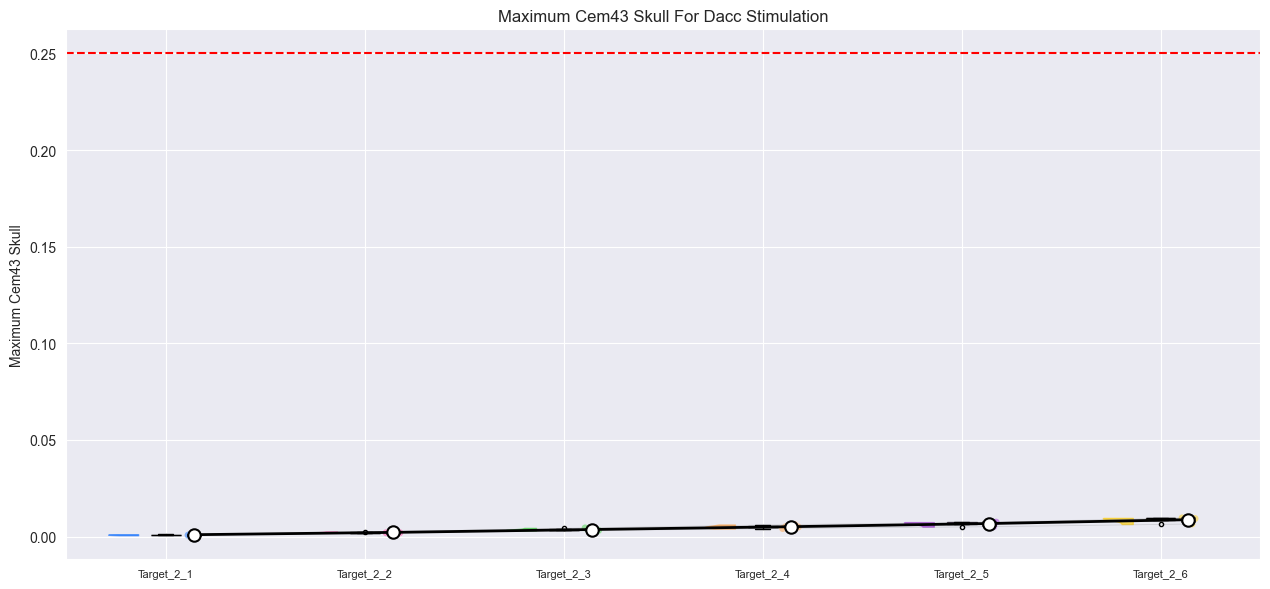

In [53]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_2_1', 'target_2_2', 'target_2_3', 'target_2_4', 'target_2_5', 'target_2_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 skull',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull for dACC stimulation'
);

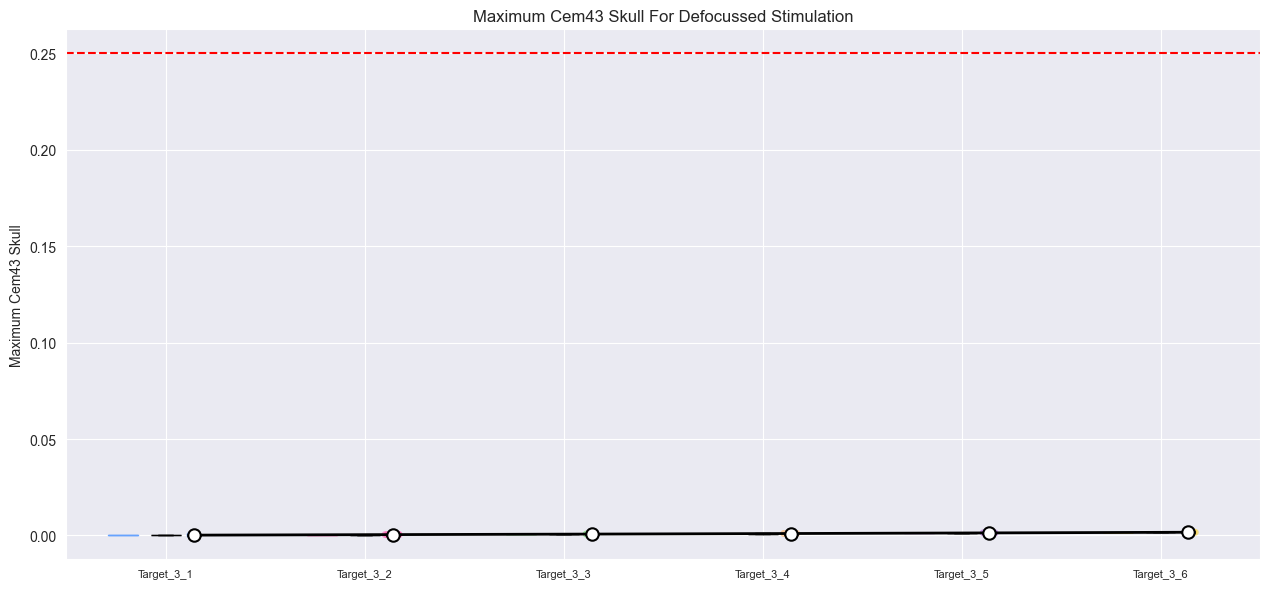

In [54]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
stimulation_output_pivoted = (
    stimulation_output
    .pivot_table(
        index=['subject_id'],
        columns='target',
        values='CEM43_skull',
        aggfunc='mean'
    )
    .reset_index()
)
stimulation_output_pivoted = stimulation_output_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    stimulation_output_pivoted,
    columns=['target_3_1', 'target_3_2', 'target_3_3', 'target_3_4', 'target_3_5', 'target_3_6'],
    output_dir=plot_dir,
    ylabel_name='Maximum CEM43 skull',
    hline=safety_limit,
    plot_name='Maximum CEM43 skull for defocussed stimulation'
);
